In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../Datasets/LP_Train.csv")

In [52]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0,146.14,360.0,1.00,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508,128.0,360.0,1.00,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0,66.0,360.0,1.00,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358,120.0,360.0,1.00,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0,141.0,360.0,1.00,Urban,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0,71.0,360.0,1.00,Rural,1
610,LP002979,Male,Yes,3,Graduate,No,4106,0,40.0,180.0,1.00,Rural,1
611,LP002983,Male,Yes,1,Graduate,No,8072,240,253.0,360.0,1.00,Urban,1
612,LP002984,Male,Yes,2,Graduate,No,7583,0,187.0,360.0,1.00,Urban,1


In [4]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [53]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [6]:
df.LoanAmount = df.LoanAmount.replace('NaN',0)

In [7]:
df.Dependents.unique()

array(['0', '1', '2', '3+', nan], dtype=object)

In [8]:
df['Dependents'] = df['Dependents'].replace(r'\+', '', regex=True)

In [9]:
df.Dependents = df.Dependents.replace(np.nan,0).astype('int64')

In [10]:
df.Gender = df.Gender.fillna(0)

In [11]:
df.Married = df.Married.fillna(0)

In [12]:
df.Self_Employed = df.Self_Employed.fillna(0)

In [13]:
df.LoanAmount = df.LoanAmount.fillna(0)

In [14]:
df.Loan_Amount_Term = df.Loan_Amount_Term.fillna(0)

In [15]:
df.Credit_History = df.Credit_History.fillna(0)

In [16]:
df.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.744300,5403.459283,1621.245798,141.166124,334.201954,0.773616
std,1.009623,6109.041673,2926.248369,88.340630,82.183884,0.418832
min,0.000000,150.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2877.500000,0.000000,98.000000,360.000000,1.000000
50%,0.000000,3812.500000,1188.500000,125.000000,360.000000,1.000000
75%,1.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,3.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [17]:
df.Gender.value_counts()

Gender
Male      489
Female    112
0          13
Name: count, dtype: int64

In [18]:
df[['Gender','Married','Dependents',
    'Education','Self_Employed','Property_Area']].value_counts()


Gender  Married  Dependents  Education     Self_Employed  Property_Area
Male    Yes      0           Graduate      No             Semiurban        40
                                                          Rural            35
                                                          Urban            32
        No       0           Graduate      No             Semiurban        24
                                                          Urban            24
                                                                           ..
        Yes      2           Not Graduate  Yes            Semiurban         1
                 3           Graduate      Yes            Rural             1
                             Not Graduate  Yes            Rural             1
                                                          Semiurban         1
                                                          Urban             1
Name: count, Length: 137, dtype: int64

In [19]:
df.Gender.unique()

array(['Male', 'Female', 0], dtype=object)

In [20]:
df.Gender = df.Gender.replace(0 ,'Male')

In [21]:
df.Married.unique()

array(['No', 'Yes', 0], dtype=object)

In [22]:
df.Married = df.Married.replace(0 ,'Yes')

In [23]:
df.Education.unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [24]:
df.Self_Employed.unique()

array(['No', 'Yes', 0], dtype=object)

In [25]:
df.Self_Employed = df.Self_Employed.replace(0,'No')

In [26]:
df.Loan_Status = df.Loan_Status.replace('Y',1)

In [27]:
df.Loan_Status = df.Loan_Status.replace('N',0)

C:\Users\MANASI\AppData\Local\Temp\ipykernel_12948\66781359.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.Loan_Status = df.Loan_Status.replace('N',0)


In [28]:
df.Loan_Status.unique()

array([1, 0])

In [29]:
df.LoanAmount = df.LoanAmount.replace(0,'146.14')

In [30]:
df.Loan_Amount_Term.unique()

array([360., 120., 240.,   0., 180.,  60., 300., 480.,  36.,  84.,  12.])

In [31]:
df.Loan_Amount_Term = df.Loan_Amount_Term.replace(0,'342').astype('float64')

In [32]:
df.Credit_History.unique()

array([1., 0.])

In [33]:
df.Credit_History = df.Credit_History.replace(0 ,'0.84').astype('float64')

In [34]:
df.Property_Area.unique()

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

Bar Plot loan approval and gender

Task3

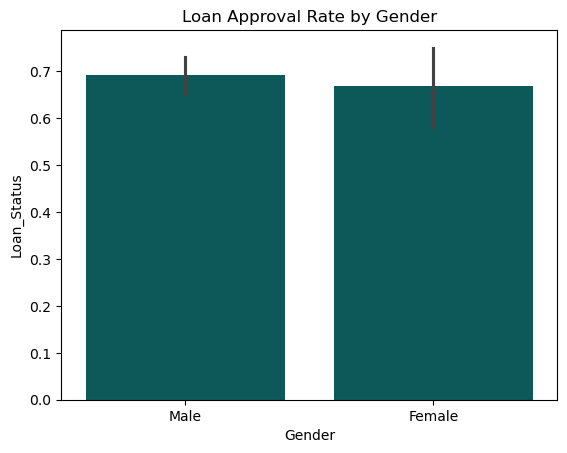

In [35]:

sb.barplot(x=df.Gender, y=df.Loan_Status, color = '#006666')
plt.title('Loan Approval Rate by Gender')
plt.show()


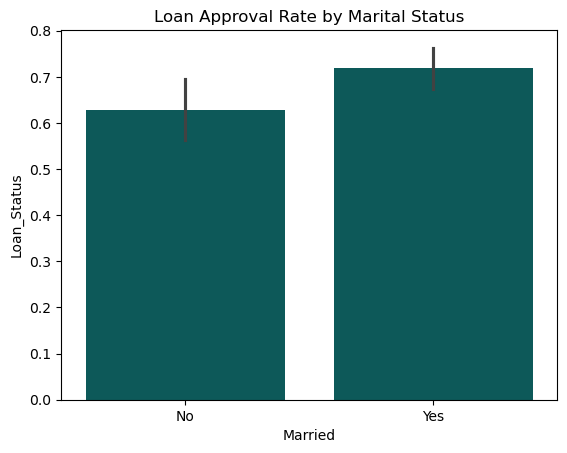

In [36]:
sb.barplot(x=df.Married, y=df.Loan_Status, color = '#006666')
plt.title('Loan Approval Rate by Marital Status')
plt.show()

In [37]:
df.Dependents.unique()

array([0, 1, 2, 3])

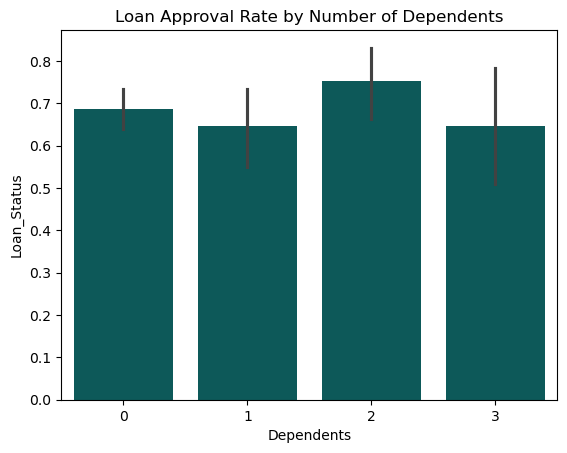

In [38]:
sb.barplot(x=df.Dependents, y= df.Loan_Status, color = '#006666')
plt.title('Loan Approval Rate by Number of Dependents')
plt.show()

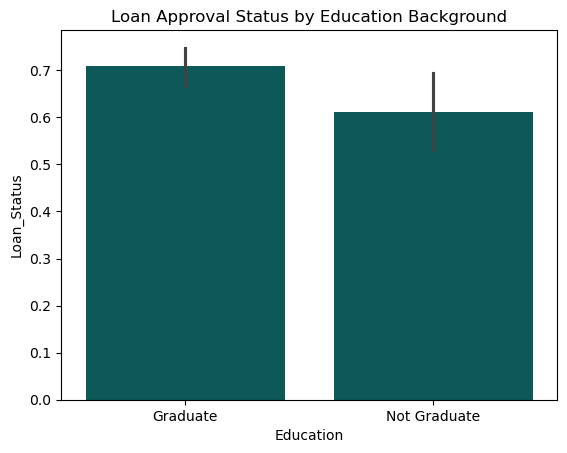

In [39]:
sb.barplot(x=df.Education, y= df.Loan_Status, color = '#006666')
plt.title('Loan Approval Status by Education Background')
plt.show()

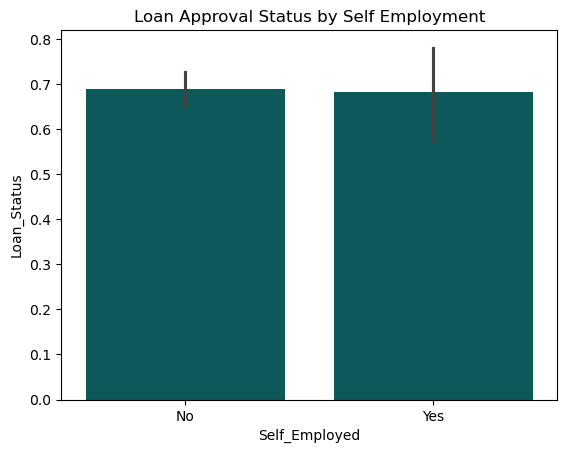

In [40]:
sb.barplot(x=df.Self_Employed, y= df.Loan_Status, color = '#006666')
plt.title('Loan Approval Status by Self Employment')
plt.show()

Task4

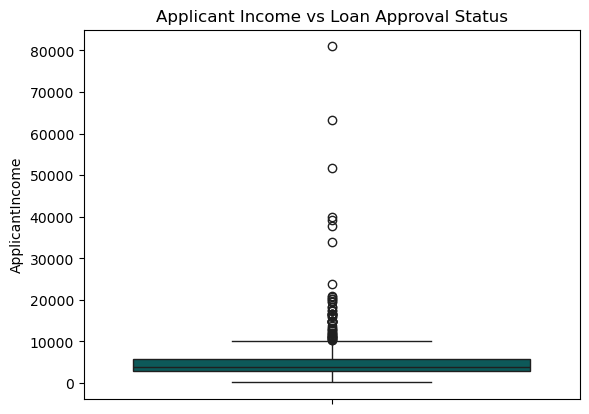

In [41]:
sb.boxplot(df.ApplicantIncome,color='#006666')
plt.title("Applicant Income vs Loan Approval Status")
plt.show()

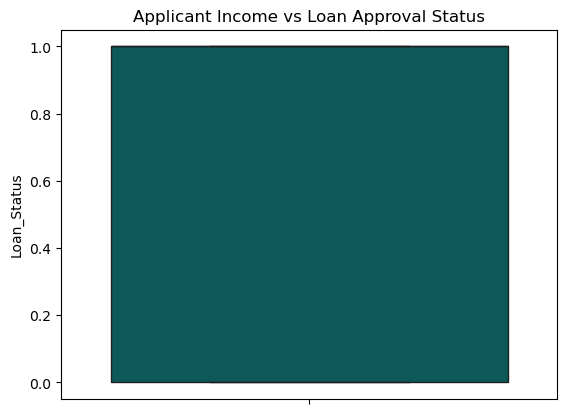

In [42]:
sb.boxplot(df.Loan_Status,color='#006666')
plt.title("Applicant Income vs Loan Approval Status")
plt.show()

In [50]:
df.CoapplicantIncome.unique()

array([    0,  1508,  2358,  4196,  1516,  2504,  1526, 10968,   700,
        1840,  8106,  2840,  1086,  3500,  5625,  1911,  1917,  2925,
        2253,  1040,  2083,  3369,  1667,  3000,  2067,  1330,  1459,
        7210,  1668,  1213,  2336,  3440,  2275,  1644,  1167,  1591,
        2200,  2250,  2859,  3796,  3449,  4595,  2254,  3066,  1875,
        1774,  4750,  3022,  4000,  2166,  1881,  2531,  2000,  2118,
        4167,  2900,  5654,  1820,  2302,   997,  3541,  3263,  3806,
        3583,   754,  1030,  1126,  3600,  2333,  4114,  2283,  1398,
        2142,  2667,  8980,  2014,  1640,  3850,  2569,  1929,  7750,
        1430,  2034,  4486,  1425,  1666,   830,  3750,  1041,  1280,
        1447,  3166,  3333,  1769,   736,  1964,  1619, 11300,  1451,
        7250,  5063,  2138,  5296,  2583,  2365,  2816,  2500,  1083,
        1250,  3021,   983,  1800,  1775,  2383,  1717,  2791,  1010,
        1695,  2054,  2598,  1779,  1260,  5000,  1983,  5701,  1300,
        4417,  4333,

In [49]:
df['CoapplicantIncome'] = df['CoapplicantIncome'].astype(int)


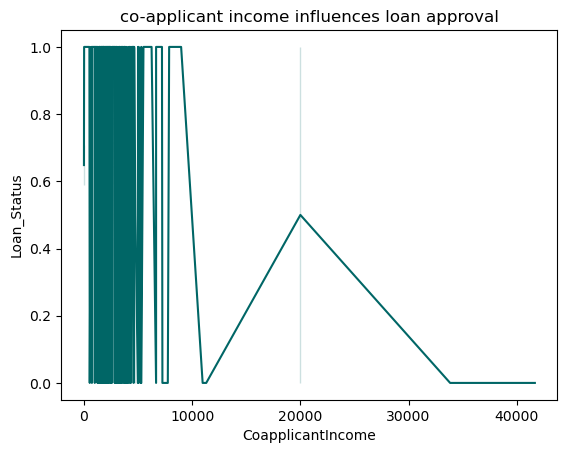

In [51]:
sb.lineplot(x=df.CoapplicantIncome , y=df.Loan_Status,color = '#006666')
plt.title("co-applicant income influences loan approval")
plt.show()

In [46]:
df.corr(numeric_only=True)

,Dependents,ApplicantIncome,CoapplicantIncome,Loan_Amount_Term,Credit_History,Loan_Status
Dependents,1.000000,0.118202,0.030429,-0.101054,-0.017523,0.010118
ApplicantIncome,0.118202,1.000000,-0.116604,-0.045242,0.006986,-0.004710
CoapplicantIncome,0.030429,-0.116604,1.000000,-0.059674,-0.058796,-0.059188
Loan_Amount_Term,-0.101054,-0.045242,-0.059674,1.000000,0.005446,-0.020974
Credit_History,-0.017523,0.006986,-0.058796,0.005446,1.000000,0.432616
Loan_Status,0.010118,-0.004710,-0.059188,-0.020974,0.432616,1.000000


In [57]:
df.groupby(["Gender","Married", "Education"])["LoanAmount"].sum()

Gender  Married  Education   
Female  No       Graduate         7820.14
                 Not Graduate     1529.14
        Yes      Graduate         4159.14
                 Not Graduate      740.00
Male    No       Graduate        14933.56
                 Not Graduate     3290.14
        Yes      Graduate        46917.26
                 Not Graduate    10501.70
Name: LoanAmount, dtype: float64

Task 5

In [58]:
 df.groupby("Credit_History")["Loan_Status"].mean()

Credit_History
0.84    0.316547
1.00    0.795789
Name: Loan_Status, dtype: float64

In [59]:
df.groupby("Loan_Amount_Term")["Loan_Status"].mean()

Loan_Amount_Term
12.0     1.000000
36.0     0.000000
60.0     1.000000
84.0     0.750000
120.0    1.000000
180.0    0.659091
240.0    0.750000
300.0    0.615385
342.0    0.571429
360.0    0.701172
480.0    0.400000
Name: Loan_Status, dtype: float64

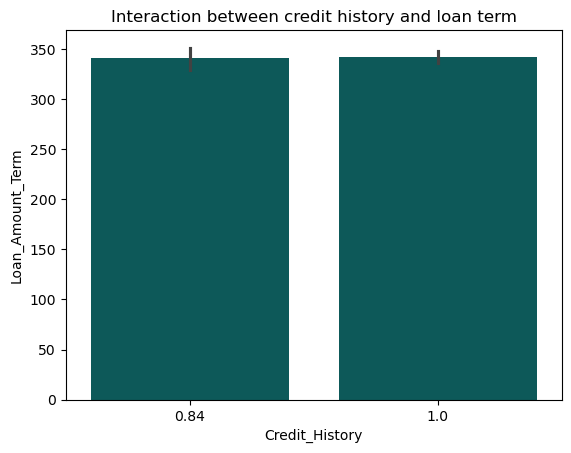

In [54]:
sb.barplot(x=df.Credit_History,y=df.Loan_Amount_Term,color = '#006666')
plt.title("Interaction between credit history and loan term")
plt.show()

Task 6

In [60]:
df.groupby('Property_Area')['Loan_Status'].sum()

Property_Area
Rural        110
Semiurban    179
Urban        133
Name: Loan_Status, dtype: int64

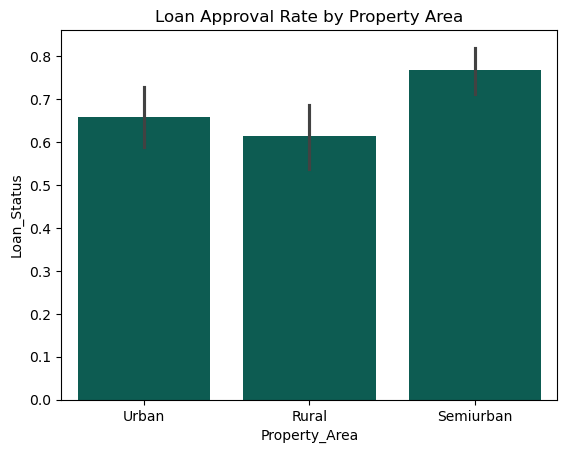

In [55]:
sb.barplot(x=df.Property_Area, y=df.Loan_Status, color='#00695C')
plt.title("Loan Approval Rate by Property Area")
plt.show()

In [ ]:
df=df.drop('Loan_Status_Percent',axis=1)